<a href="https://colab.research.google.com/github/danield595/tmp/blob/main/BSR_%5BYoY%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Conexión a la API de Keepa
# @markdown Ingresa el ASIN del producto.

import requests
from google.colab import userdata

# Parámetro del formulario ---
ASIN = "B073PVRSDL" # @param {type:"string"}
# Dominio fijo: 1 = US - Amazon.com
domain_code = 1

# API Key: se obtiene desde los Secretos de Colab ---
try:
    KEEPA_API_KEY = userdata.get('KEEPA_API_KEY')
except userdata.SecretNotFoundError:
    raise RuntimeError(
        "❌ No se encontró el secreto 'KEEPA_API_KEY' en Colab. "
        "Ve al panel izquierdo (ícono de llave 🔑) y agrégalo con ese nombre exacto."
    )
except userdata.NotebookAccessError:
    raise RuntimeError(
        "❌ El secreto 'KEEPA_API_KEY' existe pero no tiene permiso de acceso para "
        "este notebook. Ve al panel de Secretos (🔑) y activa el toggle de acceso "
        "junto a 'KEEPA_API_KEY'."
    )

if not KEEPA_API_KEY:
    raise RuntimeError("❌ El secreto 'KEEPA_API_KEY' está vacío. Verifica su valor en el panel de Secretos.")

# --- Validaciones básicas antes de gastar tokens de la API ---
ASIN = ASIN.strip().upper()

if not ASIN:
    raise ValueError("⚠️ Debes ingresar un ASIN antes de continuar.")
if len(ASIN) != 10:
    print(f"⚠️ El ASIN '{ASIN}' no tiene la longitud típica de 10 caracteres. Verifica que sea correcto.")

# --- Llamada a la API ---
# history=1 -> incluye los arrays históricos (monthlySoldHistory, priceHistory, etc.)
url = "https://api.keepa.com/product"
params = {
    "key": KEEPA_API_KEY,
    "domain": domain_code,
    "asin": ASIN,
    "history": 1,
    "stats": 180,  # ventana de stats en días; no limita el historial completo devuelto
}

print(f"🔄 Consultando Keepa para ASIN {ASIN}")

try:
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
except requests.exceptions.RequestException as e:
    raise RuntimeError(f"❌ Error de conexión con la API de Keepa: {e}")

data = resp.json()

# --- Manejo de errores propios de la respuesta de Keepa ---
if "error" in data and data["error"]:
    raise RuntimeError(f"❌ Keepa devolvió un error: {data['error']}")

tokens_restantes = data.get("tokensLeft", "N/D")
print(f"ℹ️ Tokens restantes en tu cuenta Keepa: {tokens_restantes}")

productos = data.get("products", [])

if not productos or productos[0] is None:
    raise RuntimeError(
        f"❌ No se encontró ningún producto para el ASIN '{ASIN}' en US - Amazon.com. "
        f"Verifica que el ASIN sea correcto y exista en ese marketplace."
    )

producto = productos[0]
titulo = producto.get("title", "(sin título)")

# --- NUEVO: Extraer BSR desde el array 'csv' ---
# En Keepa, el índice 3 del array 'csv' corresponde a la historia del SALES_RANK
csv_data = producto.get("csv")

if csv_data and len(csv_data) > 3 and csv_data[3]:
    bsr_history_raw = csv_data[3]
else:
    bsr_history_raw = None

if not bsr_history_raw:
    raise RuntimeError(
        f"⚠️ El producto '{titulo}' (ASIN {ASIN}) no trae historial de BSR (Sales Rank) en la respuesta. "
        f"Prueba con otro ASIN o revisa si la categoría principal tiene ranking."
    )

print(f"✅ Producto encontrado: {titulo}")
print(f"✅ Historial de BSR obtenido: {len(bsr_history_raw)//2} registros de cambio.")

🔄 Consultando Keepa para ASIN B073PVRSDL
ℹ️ Tokens restantes en tu cuenta Keepa: 299
✅ Producto encontrado: HAIBOXING 18859 1:18 Scale All Terrain RC Car, Hobby 4WD Remote Control Car
✅ Historial de BSR obtenido: 19813 registros de cambio.


In [ ]:
# @title Tabulador de BSR (Sales Rank)
import pandas as pd
from datetime import datetime, timedelta
from IPython.display import display

# --- Verificar que la Celda 1 se ejecutó antes ---
if 'bsr_history_raw' not in globals():
    raise RuntimeError("⚠️ Debes ejecutar primero la Celda 1 para traer los datos del ASIN desde la API de Keepa.")

# La API ya entrega una lista de enteros [tiempo, bsr, tiempo, bsr, ...]
# con los signos correctos — a diferencia del copy/paste manual, aquí NO hace
# falta regex para extraer números, así que ese bug queda eliminado de raíz.
valores = list(bsr_history_raw)

if len(valores) == 0:
    print("⚠️ El historial está vacío para este producto.")
else:
    # Salvaguarda por si acaso (no debería ocurrir viniendo de la API, pero se
    # mantiene el chequeo por robustez)
    if len(valores) % 2 != 0:
        print(f"⚠️ Se encontró un número impar de valores ({len(valores)}). "
              f"Se descartó el último elemento suelto para poder formar pares completos.")
        valores = valores[:len(valores) - 1]

    def keepa_to_date(keepa_minutes):
        return datetime(2011, 1, 1) + timedelta(minutes=keepa_minutes)

    datos_procesados = []
    for i in range(0, len(valores), 2):
        k_time = valores[i]
        bsr = valores[i + 1]

        # Validación: el timestamp de Keepa nunca debería ser negativo.
        if k_time < 0:
            print(f"⚠️ Timestamp negativo detectado en la posición {i} (valor={k_time}). "
                  f"Registro omitido — repórtalo si se repite, podría ser un caso raro de la API.")
            continue

        fecha_exacta = keepa_to_date(k_time)

        # -1 = "sin ranking / out of stock" (centinela estándar de Keepa)
        valor_limpio = bsr if bsr != -1 else pd.NA

        datos_procesados.append({
            'Fecha': fecha_exacta.strftime('%Y-%m-%d'),
            'Hora': fecha_exacta.strftime('%H:%M'),
            'BSR (Sales Rank)': valor_limpio
        })

    df_bsr = pd.DataFrame(datos_procesados)

    n_nulos = df_bsr['BSR (Sales Rank)'].isna().sum()
    print(f"✅ ¡Éxito! Se procesaron {len(df_bsr)} registros de cambios de BSR para "
          f"ASIN {ASIN} — {titulo}")

    if n_nulos > 0:
        print(f"ℹ️ Se detectaron {n_nulos} registros marcados como 'sin ranking' (-1 → NA).")
    print("-" * 60)

    try:
        from google.colab import data_table
        data_table.enable_dataframe_formatter()
    except ImportError:
        pass

    display(df_bsr)

✅ ¡Éxito! Se procesaron 19813 registros de cambios de BSR para ASIN B073PVRSDL — HAIBOXING 18859 1:18 Scale All Terrain RC Car, Hobby 4WD Remote Control Car
ℹ️ Se detectaron 3 registros marcados como 'sin ranking' (-1 → NA).
------------------------------------------------------------


,Fecha,Hora,BSR (Sales Rank)
0,2019-10-12,11:38,13694
1,2019-10-12,12:46,14400
2,2019-10-12,14:20,15145
3,2019-10-12,20:52,4228
4,2019-10-13,01:34,5653
...,...,...,...
19808,2026-09-10,00:48,3469
19809,2026-09-10,03:06,3472
19810,2026-09-10,11:32,3226
19811,2026-09-10,14:48,3240


In [ ]:
# @title Tabulador de BSR con LOG(BSR)
import pandas as pd
import numpy as np
from IPython.display import display

# --- Verificar que la Celda 2 se ejecutó antes ---
if 'df_bsr' not in globals():
    raise RuntimeError("⚠️ Debes ejecutar primero la Celda 2 para generar 'df_bsr'.")

# 1. Hacemos una copia para no alterar los datos de la celda anterior
df_bsr_log = df_bsr.copy()

# 2. Asegurarnos de que el BSR sea numérico
# (convierte los pd.NA a NaN que numpy puede procesar sin dar error)
df_bsr_log['BSR (Sales Rank)'] = pd.to_numeric(df_bsr_log['BSR (Sales Rank)'], errors='coerce')

# 3. Calcular el Logaritmo (Base 10) del BSR
# Los valores nulos (NaN) darán como resultado NaN en el logaritmo automáticamente
df_bsr_log['LOG(BSR)'] = np.log10(df_bsr_log['BSR (Sales Rank)'])

# Opcional: redondear a 3 decimales para que se vea más limpio en la tabla
df_bsr_log['LOG(BSR)'] = df_bsr_log['LOG(BSR)'].round(3)

print("✅ ¡Éxito! Se añadió la columna 'LOG(BSR)' al dataframe.")
print("-" * 60)

try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except ImportError:
    pass

display(df_bsr_log)

✅ ¡Éxito! Se añadió la columna 'LOG(BSR)' al dataframe.
------------------------------------------------------------


,Fecha,Hora,BSR (Sales Rank),LOG(BSR)
0,2019-10-12,11:38,13694.0,4.137
1,2019-10-12,12:46,14400.0,4.158
2,2019-10-12,14:20,15145.0,4.180
3,2019-10-12,20:52,4228.0,3.626
4,2019-10-13,01:34,5653.0,3.752
...,...,...,...,...
19808,2026-09-10,00:48,3469.0,3.540
19809,2026-09-10,03:06,3472.0,3.541
19810,2026-09-10,11:32,3226.0,3.509
19811,2026-09-10,14:48,3240.0,3.511


In [ ]:
# @title Estadísticas de Volatilidad: Varianza y Desviación Estándar del LOG(BSR)
import pandas as pd
from IPython.display import display

# --- Verificar que la Celda 3 se ejecutó antes ---
if 'df_bsr_log' not in globals():
    raise RuntimeError("⚠️ Debes ejecutar primero la Celda 3 para generar 'df_bsr_log'.")

# 1. Hacemos una copia y aseguramos el formato de fecha
df_stats = df_bsr_log.copy()
df_stats['Fecha_DT'] = pd.to_datetime(df_stats['Fecha'])

# 2. Eliminar valores nulos para un cálculo estadístico preciso
df_stats = df_stats.dropna(subset=['LOG(BSR)'])

# 3. Determinar la fecha más reciente en el historial del producto
fecha_max = df_stats['Fecha_DT'].max()

# 4. Definir las ventanas de tiempo
ventana_1_anio = fecha_max - pd.DateOffset(years=1)
ventana_6_meses = fecha_max - pd.DateOffset(months=6)
ventana_3_meses = fecha_max - pd.DateOffset(months=3)
ventana_1_mes = fecha_max - pd.DateOffset(months=1)

# 5. Filtrar los DataFrames para cada periodo
df_1_anio = df_stats[df_stats['Fecha_DT'] >= ventana_1_anio]
df_6_meses = df_stats[df_stats['Fecha_DT'] >= ventana_6_meses]
df_3_meses = df_stats[df_stats['Fecha_DT'] >= ventana_3_meses]
df_1_mes = df_stats[df_stats['Fecha_DT'] >= ventana_1_mes]

# 6. Calcular estadísticas y armar el resumen
resultados = [
    {
        "Periodo": "Toda la historia",
        "Varianza": df_stats['LOG(BSR)'].var(),
        "Desviación Estándar": df_stats['LOG(BSR)'].std(),
        "Registros Analizados": len(df_stats)
    },
    {
        "Periodo": "Último Año (12m)",
        "Varianza": df_1_anio['LOG(BSR)'].var(),
        "Desviación Estándar": df_1_anio['LOG(BSR)'].std(),
        "Registros Analizados": len(df_1_anio)
    },
    {
        "Periodo": "Últimos 6 Meses",
        "Varianza": df_6_meses['LOG(BSR)'].var(),
        "Desviación Estándar": df_6_meses['LOG(BSR)'].std(),
        "Registros Analizados": len(df_6_meses)
    },
    {
        "Periodo": "Últimos 3 Meses",
        "Varianza": df_3_meses['LOG(BSR)'].var(),
        "Desviación Estándar": df_3_meses['LOG(BSR)'].std(),
        "Registros Analizados": len(df_3_meses)
    },
    {
        "Periodo": "Último Mes",
        "Varianza": df_1_mes['LOG(BSR)'].var(),
        "Desviación Estándar": df_1_mes['LOG(BSR)'].std(),
        "Registros Analizados": len(df_1_mes)
    }
]

df_volatilidad = pd.DataFrame(resultados)

# 7. Redondear y formatear para mejor lectura
df_volatilidad['Varianza'] = df_volatilidad['Varianza'].round(4)
df_volatilidad['Desviación Estándar'] = df_volatilidad['Desviación Estándar'].round(4)

print("✅ ¡Éxito! Cálculo de volatilidad del LOG(BSR) completado.")
print("ℹ️ Una Desviación Estándar baja indica que el producto mantiene un ranking estable.")
print("-" * 75)

try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except ImportError:
    pass

display(df_volatilidad)

✅ ¡Éxito! Cálculo de volatilidad del LOG(BSR) completado.
ℹ️ Una Desviación Estándar baja indica que el producto mantiene un ranking estable.
---------------------------------------------------------------------------


,Periodo,Varianza,Desviación Estándar,Registros Analizados
0,Toda la historia,0.1100,0.3316,19810
1,Último Año (12m),0.0302,0.1738,2021
2,Últimos 6 Meses,0.0204,0.1428,902
3,Últimos 3 Meses,0.0248,0.1574,332
4,Último Mes,0.0161,0.1271,118


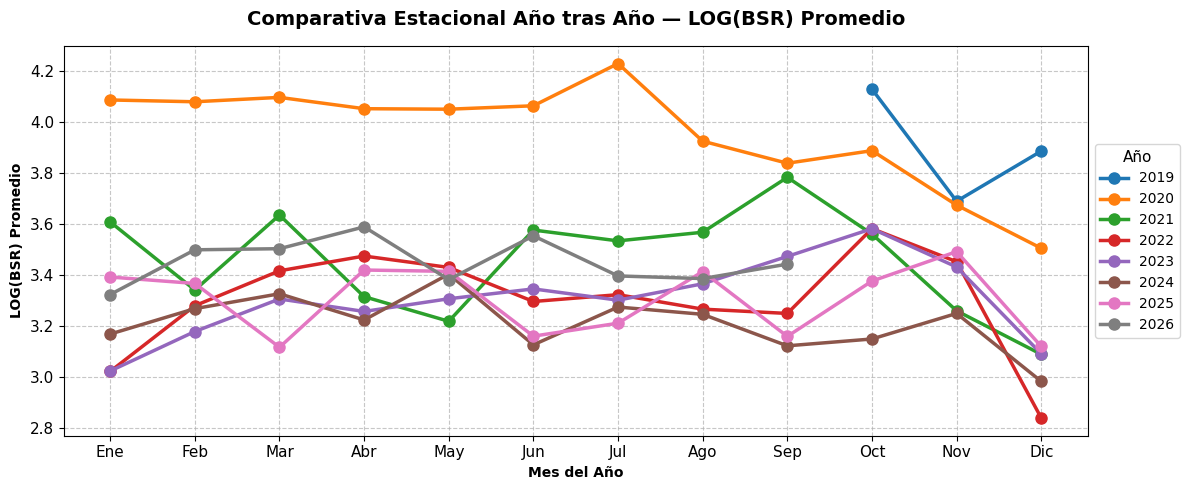

ℹ️ El gráfico muestra el LOG(BSR) promedio mensual.
⚠️ OJO: Recuerda que un LOG(BSR) menor significa un mejor ranking (más ventas).


In [ ]:
# @title Gráfico Comparativo Año tras Año - LOG(BSR)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparar los datos a partir del DataFrame df_bsr_log
if 'df_bsr_log' not in globals():
    raise RuntimeError("⚠️ Debes ejecutar la Celda 3 para generar 'df_bsr_log'.")

df_plot_log = df_bsr_log.copy()

# Asegurarnos de que 'Fecha' es datetime para extraer el año y el mes
df_plot_log['Fecha_DT'] = pd.to_datetime(df_plot_log['Fecha'])
df_plot_log['Año'] = df_plot_log['Fecha_DT'].dt.year
df_plot_log['Mes_Num'] = df_plot_log['Fecha_DT'].dt.month

# Agrupamos por Año y Mes para sacar el LOG(BSR) Promedio
# (mean() ignora automáticamente los NaN)
df_agrupado_log = df_plot_log.groupby(['Año', 'Mes_Num'])['LOG(BSR)'].mean().reset_index()

# 2. Pivotar la tabla: Índice = Meses, Columnas = Años, Valores = LOG(BSR) Promedio
df_pivot_log = df_agrupado_log.pivot(index='Mes_Num', columns='Año', values='LOG(BSR)')

# Mapear los números de los meses a texto para el eje X
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# ============================================================
# GRÁFICO — Comparativa Estacional Año tras Año en LOG(BSR)
# ============================================================
plt.figure(figsize=(12, 5))

for año in df_pivot_log.columns:
    plt.plot(
        df_pivot_log.index,
        df_pivot_log[año],
        marker='o',
        linewidth=2.5,
        markersize=8,
        label=str(año)
    )

plt.title('Comparativa Estacional Año tras Año — LOG(BSR) Promedio', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mes del Año', fontsize=10, fontweight='bold')
plt.ylabel('LOG(BSR) Promedio', fontsize=10, fontweight='bold')
plt.xticks(ticks=range(1, 13), labels=nombres_meses, fontsize=11)
plt.yticks(fontsize=11)

# Movemos la leyenda un poco afuera si hay muchos años para que no tape el gráfico
plt.legend(title='Año', title_fontsize='11', fontsize='10', loc='center left', bbox_to_anchor=(1, 0.5))

plt.grid(True, linestyle='--', alpha=0.7)

# --- Opcional: Invertir el eje Y ---
# Descomenta la siguiente línea si quieres que los valores menores de LOG(BSR)
# (que equivalen a MEJORES ventas) aparezcan en la parte superior del gráfico.
# plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("ℹ️ El gráfico muestra el LOG(BSR) promedio mensual.")
print("⚠️ OJO: Recuerda que un LOG(BSR) menor significa un mejor ranking (más ventas).")

In [ ]:
# @title Tabulador Año tras Año - LOG(BSR)
import pandas as pd
from IPython.display import display

# --- Verificar que la Celda 3 se ejecutó antes ---
if 'df_bsr_log' not in globals():
    raise RuntimeError("⚠️ Debes ejecutar primero la Celda 3 para generar 'df_bsr_log'.")

# 1. Preparar una copia de los datos
df_tab = df_bsr_log.copy()

# 2. Extraer el Año y el Mes de la columna Fecha
df_tab['Fecha_DT'] = pd.to_datetime(df_tab['Fecha'])
df_tab['Año'] = df_tab['Fecha_DT'].dt.year
df_tab['Mes_Num'] = df_tab['Fecha_DT'].dt.month

# 3. Agrupar por Año y Mes para calcular el LOG(BSR) Promedio
# La función mean() de pandas ignora automáticamente los valores nulos (NaN)
df_agrupado = df_tab.groupby(['Año', 'Mes_Num'])['LOG(BSR)'].mean().reset_index()

# Redondear a 3 decimales para mantener la tabla limpia
df_agrupado['LOG(BSR)'] = df_agrupado['LOG(BSR)'].round(3)

# 4. Pivotar la tabla: Índice = Meses, Columnas = Años, Valores = LOG(BSR) Promedio
df_pivot_log = df_agrupado.pivot(index='Mes_Num', columns='Año', values='LOG(BSR)')

# 5. Mapear los números de los meses a sus nombres en texto para mejor lectura
nombres_meses = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

df_pivot_log.index = df_pivot_log.index.map(nombres_meses)
df_pivot_log.index.name = 'Mes'

print("✅ ¡Éxito! Aquí tienes la tabla comparativa Año tras Año del LOG(BSR) promedio.")
print("-" * 60)

try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except ImportError:
    pass

display(df_pivot_log)

✅ ¡Éxito! Aquí tienes la tabla comparativa Año tras Año del LOG(BSR) promedio.
------------------------------------------------------------


Año,2019,2020,2021,2022,2023,2024,2025,2026
Mes,,,,,,,,
Enero,NaN,4.086,3.608,3.022,3.024,3.168,3.392,3.323
Febrero,NaN,4.079,3.341,3.279,3.178,3.268,3.367,3.498
Marzo,NaN,4.096,3.635,3.416,3.306,3.326,3.116,3.503
Abril,NaN,4.051,3.315,3.474,3.257,3.224,3.419,3.588
Mayo,NaN,4.049,3.218,3.429,3.307,3.403,3.414,3.382
Junio,NaN,4.063,3.576,3.296,3.345,3.126,3.160,3.553
Julio,NaN,4.228,3.533,3.323,3.301,3.274,3.211,3.396
Agosto,NaN,3.924,3.567,3.266,3.365,3.246,3.413,3.386
Septiembre,NaN,3.838,3.782,3.249,3.473,3.122,3.159,3.442


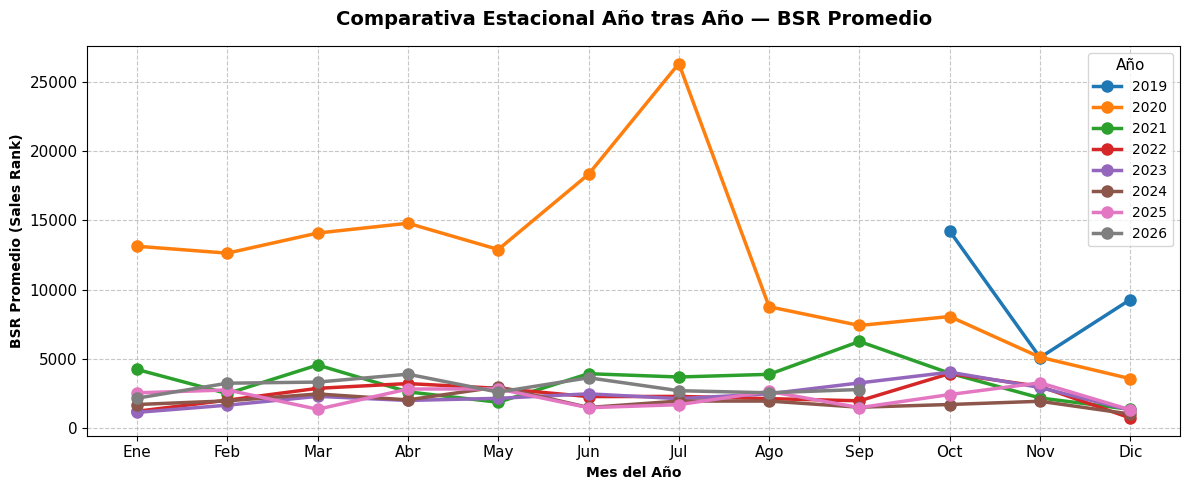

ℹ️ El gráfico muestra el BSR promedio mensual.
⚠️ OJO: Recuerda que en BSR, una línea que cae (hacia el 1) significa que las ventas SUBEN.


In [ ]:
# @title Gráfico Comparativo Año tras Año (BSR)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparar los datos a partir del DataFrame df_bsr
if 'df_bsr' not in globals():
    raise RuntimeError("⚠️ Debes ejecutar la Celda 2 para generar 'df_bsr'.")

df_plot = df_bsr.copy()

# Asegurarnos de que 'Fecha' es datetime para extraer el año y el mes
df_plot['Fecha_DT'] = pd.to_datetime(df_plot['Fecha'])
df_plot['Año'] = df_plot['Fecha_DT'].dt.year
df_plot['Mes_Num'] = df_plot['Fecha_DT'].dt.month

# Convertimos BSR a numérico (los pd.NA se vuelven NaN para poder promediar)
df_plot['BSR (Sales Rank)'] = pd.to_numeric(df_plot['BSR (Sales Rank)'], errors='coerce')

# Agrupamos por Año y Mes para sacar el BSR Promedio
df_agrupado = df_plot.groupby(['Año', 'Mes_Num'])['BSR (Sales Rank)'].mean().reset_index()

# 2. Pivotar la tabla: Índice = Meses, Columnas = Años, Valores = BSR Promedio
df_pivot = df_agrupado.pivot(index='Mes_Num', columns='Año', values='BSR (Sales Rank)')

# Mapear los números de los meses a texto para el eje X
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# ============================================================
# GRÁFICO 1 — Comparativa en BSR Absoluto
# ============================================================
plt.figure(figsize=(12, 5))

for año in df_pivot.columns:
    plt.plot(
        df_pivot.index,
        df_pivot[año],
        marker='o',
        linewidth=2.5,
        markersize=8,
        label=str(año)
    )

plt.title('Comparativa Estacional Año tras Año — BSR Promedio', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mes del Año', fontsize=10, fontweight='bold')
plt.ylabel('BSR Promedio (Sales Rank)', fontsize=10, fontweight='bold')
plt.xticks(ticks=range(1, 13), labels=nombres_meses, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Año', title_fontsize='11', fontsize='10', loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("ℹ️ El gráfico muestra el BSR promedio mensual.")
print("⚠️ OJO: Recuerda que en BSR, una línea que cae (hacia el 1) significa que las ventas SUBEN.")